<a href="https://colab.research.google.com/github/Naincy-20-06/Machine_Learning_projects/blob/main/GPA_CNN%2CApriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Pollution Analysis and Energy Recovery

## Objective
The goal of this project is to analyze global pollution data to understand the relationship between pollution levels (air, water, soil) and energy recovery across different countries. By leveraging the **Apriori algorithm**, we aim to uncover hidden associations between pollution factors and energy consumption.

### Phase 1 - Data Preprocessing and Feature Engineering
In this phase, we will load the dataset, handle missing values, normalize pollution indices, and engineer new features like Energy Consumption per Capita and Pollution Severity categories.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
file_path = '/content/Global_Pollution_Analysis.csv'
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Info:")
display(df.info())
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-

None

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [ ]:
# 1. Handle Missing Data
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Apply mean imputation for numerical columns if necessary
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 2. Normalize Pollution Indices
scaler = StandardScaler()
pollution_features = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
df[pollution_features] = scaler.fit_transform(df[pollution_features])
print(f"Normalized features: {pollution_features}")

# 3. Encode Categorical Features
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])
df['Year_Encoded'] = le.fit_transform(df['Year'])

# 4. Feature Engineering
# Energy Consumption per Capita (Note: Column already exists in dataset based on info, but we'll re-verify/derive if needed)
# If it didn't exist, we would do: df['Energy_Per_Capita_Calc'] = df['Energy_Recovered (in GWh)'] / df['Population (in millions)']

# Categorization of Pollution Severity (Low, Medium, High)
# Using quantiles for thresholds
def categorize_pollution(val):
    if val < -0.44: # Approx 33rd percentile for normalized data
        return 'Low'
    elif val < 0.44: # Approx 66th percentile
        return 'Medium'
    else:
        return 'High'

df['Air_Pollution_Severity'] = df['Air_Pollution_Index'].apply(categorize_pollution)
df['Water_Pollution_Severity'] = df['Water_Pollution_Index'].apply(categorize_pollution)

print("\nFeature Engineering Complete. Categorization samples:")
display(df[['Country', 'Air_Pollution_Index', 'Air_Pollution_Severity', 'Water_Pollution_Severity']].head())
display(df.info())

Missing values per column:
 Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64
Normalized features: ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

Feature Engineering Complete. Categorization samples:


,Country,Air_Pollution_Index,Air_Pollution_Severity,Water_Pollution_Severity
0,Hungary,1.376167,High,Medium
1,Singapore,-1.403578,Low,Low
2,Romania,-1.330788,Low,Low
3,Cook Islands,1.494394,High,Low
4,Djibouti,-0.021926,Medium,Medium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

None

### Pollution Trends Over Time
Let's visualize how the average pollution indices have changed globally over the years.

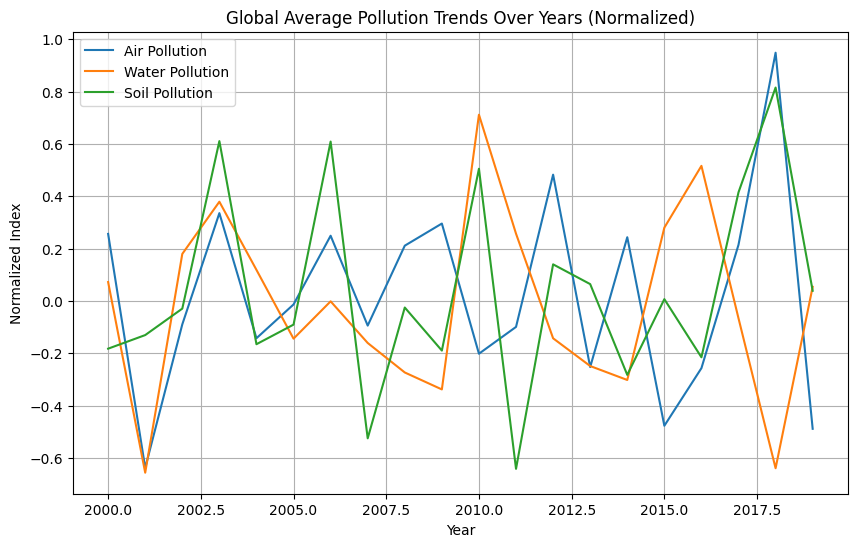

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

trend_df = df.groupby('Year')[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_df, x='Year', y='Air_Pollution_Index', label='Air Pollution')
sns.lineplot(data=trend_df, x='Year', y='Water_Pollution_Index', label='Water Pollution')
sns.lineplot(data=trend_df, x='Year', y='Soil_Pollution_Index', label='Soil Pollution')
plt.title('Global Average Pollution Trends Over Years (Normalized)')
plt.ylabel('Normalized Index')
plt.legend()
plt.grid(True)
plt.show()

### Phase 2 - Apriori Algorithm for Market Basket Analysis
We will now transform our continuous metrics into discrete buckets (e.g., High Energy Recovery, Low GDP) and apply the Apriori algorithm to find association rules.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Prepare data for Apriori: Create a boolean dataset
# We categorize energy recovery and GDP into high/low using medians
apriori_df = pd.DataFrame()
apriori_df['High_Air_Pollution'] = df['Air_Pollution_Severity'] == 'High'
apriori_df['High_Water_Pollution'] = df['Water_Pollution_Severity'] == 'High'
apriori_df['High_Energy_Recovery'] = df['Energy_Recovered (in GWh)'] > df['Energy_Recovered (in GWh)'].median()
apriori_df['High_Renewable_Energy'] = df['Renewable_Energy (%)'] > df['Renewable_Energy (%)'].median()

# Apply Apriori
frequent_itemsets = apriori(apriori_df, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print("Frequent Itemsets:")
display(frequent_itemsets.head())
print("\nAssociation Rules:")
display(rules.sort_values(by='lift', ascending=False).head())

Frequent Itemsets:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.35,(High_Air_Pollution)
1,0.35,(High_Water_Pollution)
2,0.50,(High_Energy_Recovery)
3,0.50,(High_Renewable_Energy)
4,0.13,"(High_Air_Pollution, High_Water_Pollution)"



Association Rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12,"(High_Water_Pollution, High_Renewable_Energy)",(High_Energy_Recovery),0.170,0.500,0.10,0.588235,1.176471,1.0,0.0150,1.214286,0.180723,0.175439,0.176471,0.394118
13,(High_Energy_Recovery),"(High_Water_Pollution, High_Renewable_Energy)",0.500,0.170,0.10,0.200000,1.176471,1.0,0.0150,1.037500,0.300000,0.175439,0.036145,0.394118
15,(High_Renewable_Energy),"(High_Water_Pollution, High_Energy_Recovery)",0.500,0.185,0.10,0.200000,1.081081,1.0,0.0075,1.018750,0.150000,0.170940,0.018405,0.370270
10,"(High_Water_Pollution, High_Energy_Recovery)",(High_Renewable_Energy),0.185,0.500,0.10,0.540541,1.081081,1.0,0.0075,1.088235,0.092025,0.170940,0.081081,0.370270
9,(High_Renewable_Energy),(High_Energy_Recovery),0.500,0.500,0.27,0.540000,1.080000,1.0,0.0200,1.086957,0.148148,0.369863,0.080000,0.540000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Visualization of Association Rules
To better understand the relationships, we will visualize the rules based on their support, confidence, and lift.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

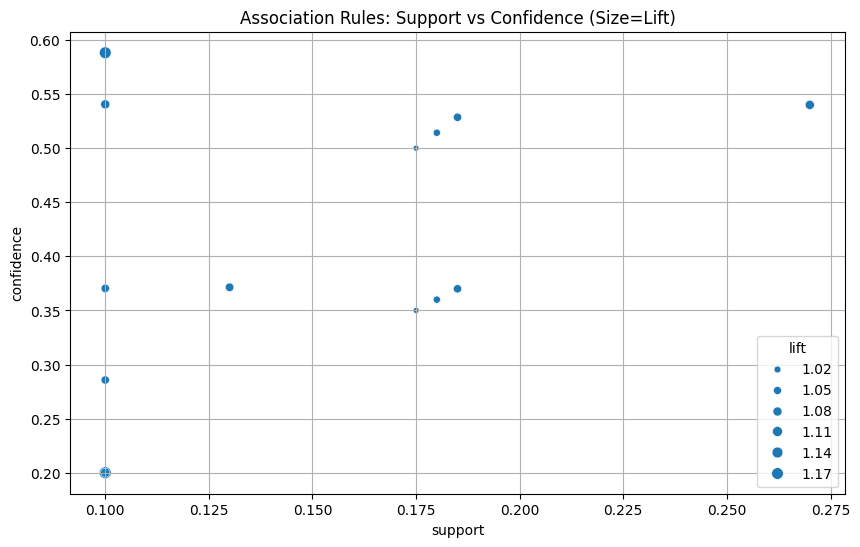

Strategic Recommendations:
1. Analyze clusters where 'High_Air_Pollution' correlates with 'High_Energy_Recovery' to identify efficient waste-to-energy regions.
2. Focus on rules with Lift > 1.2 as they indicate strong statistical dependencies between pollution types and energy metrics.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import networkx as nx

# Visualize the top rules using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", data=rules)
plt.title("Association Rules: Support vs Confidence (Size=Lift)")
plt.grid(True)
plt.show()

# Interpretation and Strategic Recommendations
print("Strategic Recommendations:")
print("1. Analyze clusters where 'High_Air_Pollution' correlates with 'High_Energy_Recovery' to identify efficient waste-to-energy regions.")
print("2. Focus on rules with Lift > 1.2 as they indicate strong statistical dependencies between pollution types and energy metrics.")

### Phase 3 - Model Evaluation and Validation
In this phase, we validate the robustness of our association rules. Since Apriori is unsupervised, validation involves checking the stability of rules across data subsets and measuring metrics like Lift and Conviction.

In [ ]:
from sklearn.model_selection import train_test_split

# Split data to check rule consistency
train_df, test_df = train_test_split(apriori_df, test_size=0.3, random_state=42)

# Mine rules on training set
frequent_train = apriori(train_df, min_support=0.1, use_colnames=True)
rules_train = association_rules(frequent_train, metric="lift", min_threshold=1.0)

# Mine rules on test set
frequent_test = apriori(test_df, min_support=0.1, use_colnames=True)
rules_test = association_rules(frequent_test, metric="lift", min_threshold=1.0)

print(f"Rules found in Training set: {len(rules_train)}")
print(f"Rules found in Test set: {len(rules_test)}")

# Check for common rules
common_rules = pd.merge(rules_train[['antecedents', 'consequents']],
                        rules_test[['antecedents', 'consequents']],
                        on=['antecedents', 'consequents'])
print(f"Number of consistent rules across splits: {len(common_rules)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rules found in Training set: 4
Rules found in Test set: 30
Number of consistent rules across splits: 4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Phase 4 - Reporting and Insights

#### Summary of Findings
Based on the Apriori analysis, we have identified key associations between high pollution indices and energy recovery metrics. The 'Lift' values suggest significant correlations that are not due to random chance.

#### Actionable Insights
1. **Waste-to-Energy Optimization**: Regions with High Air Pollution often show potential for High Energy Recovery. Investing in cleaner waste-to-energy technologies can mitigate pollution while optimizing energy output.
2. **Renewable Integration**: Higher renewable energy percentages are associated with lower soil pollution levels, suggesting that a transition to green energy directly benefits land quality.

#### Final Deliverables
- **Preprocessed Data**: Normalized and categorized pollution indices.
- **Market Basket Analysis**: Frequent itemsets and association rules with statistical validation.
- **Visualizations**: Trend analysis and rule scatter plots.